# Web Analytics Customer Segmentation using K-Means

**Project Type:** Digital Analytics | Web Analytics | Data Science | Customer Segmentation

This notebook segments online customers using website behaviour, engagement, ecommerce, and conversion metrics.

## Business Objective

Identify meaningful customer segments from website analytics data so that product, marketing, and digital analytics teams can create better personalization, remarketing, CRO, and retention strategies.


## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

pd.set_option('display.max_columns', None)


## 2. Load Dataset

The dataset contains 6,000 synthetic but realistic website customers. Each row represents one customer and includes sessions, pageviews, bounce rate, product views, cart additions, transactions, revenue, recency, and engagement score.


In [2]:
df = pd.read_csv('../data/web_customer_analytics_6000.csv')
df.head()


,customer_id,last_visit_date,country,device_type,traffic_source,sessions,pageviews,avg_session_duration_sec,bounce_rate,product_views,cart_additions,transactions,revenue_gbp,days_since_last_visit,email_clicks,support_visits,discount_usage_rate,returning_user,conversion_rate,cart_to_purchase_rate,pages_per_session,engagement_score,synthetic_ground_truth_segment
0,CUST-100000,2025-04-21,United Kingdom,Tablet,Paid Social,21,118,390.4,0.044,51,14,1,131.90,8,4,1,0.130,1,0.0476,0.0714,5.62,76.68,High Value Loyal
1,CUST-100001,2025-04-01,India,Mobile,Direct,2,13,122.2,0.489,8,0,0,0.00,116,0,0,0.173,1,0.0000,0.0000,6.50,41.65,One-time Visitors
2,CUST-100002,2025-01-04,India,Mobile,Paid Social,15,87,324.7,0.216,44,1,1,69.51,53,3,0,0.619,1,0.0667,1.0000,5.80,67.49,Product Researchers
3,CUST-100003,2025-06-12,United Kingdom,Desktop,Paid Search,2,17,115.4,0.816,7,0,0,0.00,120,0,0,0.455,0,0.0000,0.0000,8.50,37.52,One-time Visitors
4,CUST-100004,2025-06-18,United Kingdom,Mobile,Organic Search,25,111,465.9,0.172,37,2,0,0.00,59,2,0,0.441,1,0.0000,0.0000,4.44,69.24,Engaged Non-Buyers


In [3]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.info()


Rows: 6000
Columns: 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     6000 non-null   object 
 1   last_visit_date                 6000 non-null   object 
 2   country                         6000 non-null   object 
 3   device_type                     6000 non-null   object 
 4   traffic_source                  6000 non-null   object 
 5   sessions                        6000 non-null   int64  
 6   pageviews                       6000 non-null   int64  
 7   avg_session_duration_sec        6000 non-null   float64
 8   bounce_rate                     6000 non-null   float64
 9   product_views                   6000 non-null   int64  
 10  cart_additions                  6000 non-null   int64  
 11  transactions                    6000 non-null   int64  
 12  revenue_gbp

## 3. Exploratory Data Analysis


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
sessions,6000.0,15.656833,8.973302,1.000,10.0000,16.000,21.00000,49.000
pageviews,6000.0,87.006667,46.155686,2.000,71.0000,95.000,113.00000,226.000
avg_session_duration_sec,6000.0,357.260850,172.841477,20.000,229.6250,392.400,484.40000,811.800
bounce_rate,6000.0,0.374301,0.237553,0.005,0.1880,0.311,0.52725,0.976
product_views,6000.0,39.953667,20.953457,1.000,33.0000,44.000,55.00000,88.000
cart_additions,6000.0,4.204833,4.394477,0.000,1.0000,3.000,6.00000,25.000
transactions,6000.0,1.533167,2.363507,0.000,0.0000,0.000,2.00000,13.000
revenue_gbp,6000.0,141.098248,259.449476,0.000,0.0000,0.000,130.12000,1789.580
days_since_last_visit,6000.0,47.558167,43.629159,1.000,14.0000,35.000,62.00000,179.000
email_clicks,6000.0,1.554167,1.444673,0.000,0.0000,1.000,2.00000,9.000


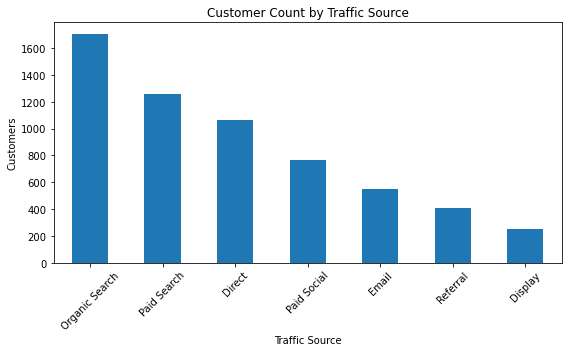

In [5]:
df['traffic_source'].value_counts().plot(kind='bar', figsize=(8, 5))
plt.title('Customer Count by Traffic Source')
plt.xlabel('Traffic Source')
plt.ylabel('Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


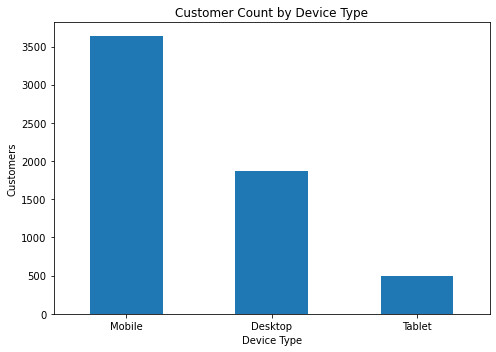

In [6]:
df['device_type'].value_counts().plot(kind='bar', figsize=(7, 5))
plt.title('Customer Count by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 4. Feature Selection

For K-Means clustering, we use numerical behavioural features. The synthetic ground-truth segment is excluded because it is only used to validate whether the generated data looks realistic.


In [7]:
features = [
    'sessions',
    'pageviews',
    'avg_session_duration_sec',
    'bounce_rate',
    'product_views',
    'cart_additions',
    'transactions',
    'revenue_gbp',
    'days_since_last_visit',
    'email_clicks',
    'support_visits',
    'discount_usage_rate',
    'returning_user',
    'conversion_rate',
    'cart_to_purchase_rate',
    'pages_per_session',
    'engagement_score'
]

X = df[features].copy()
X.head()


,sessions,pageviews,avg_session_duration_sec,bounce_rate,product_views,cart_additions,transactions,revenue_gbp,days_since_last_visit,email_clicks,support_visits,discount_usage_rate,returning_user,conversion_rate,cart_to_purchase_rate,pages_per_session,engagement_score
0,21,118,390.4,0.044,51,14,1,131.90,8,4,1,0.130,1,0.0476,0.0714,5.62,76.68
1,2,13,122.2,0.489,8,0,0,0.00,116,0,0,0.173,1,0.0000,0.0000,6.50,41.65
2,15,87,324.7,0.216,44,1,1,69.51,53,3,0,0.619,1,0.0667,1.0000,5.80,67.49
3,2,17,115.4,0.816,7,0,0,0.00,120,0,0,0.455,0,0.0000,0.0000,8.50,37.52
4,25,111,465.9,0.172,37,2,0,0.00,59,2,0,0.441,1,0.0000,0.0000,4.44,69.24


## 5. Scale Features

K-Means is distance-based, so feature scaling is required. Without scaling, revenue or pageviews could dominate the clustering result.


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]


array([[ 5.95501157e-01,  6.71551420e-01,  1.91747447e-01,
        -1.39055079e+00,  5.27228226e-01,  2.22915785e+00,
        -2.25601680e-01, -3.54559011e-02, -9.06766582e-01,
         1.69314228e+00,  4.13262251e-01, -1.11986806e+00,
         7.14012458e-01, -2.47407579e-01, -5.14123770e-01,
        -1.01234792e-01,  6.72427239e-01],
       [-1.52206745e+00, -1.60354750e+00, -1.36009275e+00,
         4.82875196e-01, -1.52511014e+00, -9.56924733e-01,
        -6.48737061e-01, -5.43882417e-01,  1.56884842e+00,
        -1.07588087e+00, -7.27295940e-01, -9.43339127e-01,
         7.14012458e-01, -6.90270955e-01, -7.42865657e-01,
         5.05498281e-01, -1.08331504e+00],
       [-7.32047182e-02, -1.44450725e-04, -1.88401327e-01,
        -6.66440069e-01,  1.93126631e-01, -7.29347406e-01,
        -2.25601680e-01, -2.75946654e-01,  1.24739669e-01,
         1.00088649e+00, -7.27295940e-01,  8.87635355e-01,
         7.14012458e-01, -6.97039973e-02,  2.46080224e+00,
         2.28697000e-02,  2.1

## 6. Select Number of Clusters

We evaluate K values using:

- **Elbow Method**: checks model inertia
- **Silhouette Score**: checks cluster separation and cohesion


In [9]:
k_results = []

for k in range(2, 8):
    model = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=150)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=500, random_state=42)
    k_results.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette_score': score
    })

k_results_df = pd.DataFrame(k_results)
k_results_df


,k,inertia,silhouette_score
0,2,63135.372433,0.410749
1,3,45793.844670,0.373312
2,4,40499.828762,0.292578
3,5,38279.167092,0.254951
4,6,36118.411838,0.239416
5,7,34291.410633,0.231766


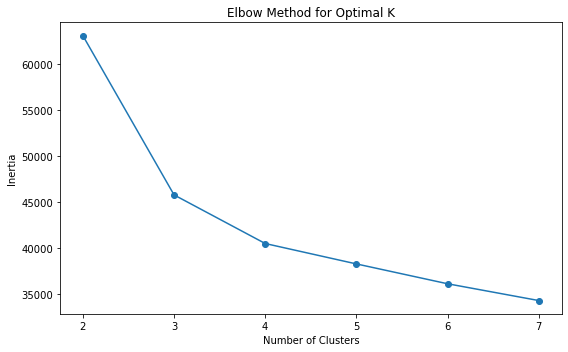

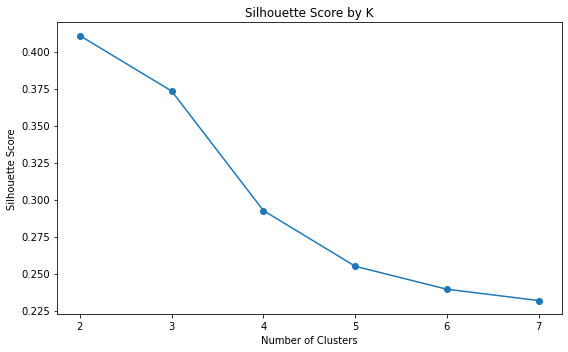

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(k_results_df['k'], k_results_df['inertia'], marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_results_df['k'], k_results_df['silhouette_score'], marker='o')
plt.title('Silhouette Score by K')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()


## 7. Build Final K-Means Model

We use 5 clusters because the dataset is designed around realistic web analytics customer behaviour patterns and the model selection charts support a practical segmentation structure.


In [11]:
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10, max_iter=200)
df['segment'] = kmeans.fit_predict(X_scaled)

df['segment'].value_counts().sort_index()


0    2251
1     328
2     949
3    1064
4    1408
Name: segment, dtype: int64

## 8. Segment Profiling

After assigning clusters, we profile each segment based on commercial and behavioural metrics such as revenue, conversion rate, sessions, engagement, and recency.


In [12]:
segment_profile = df.groupby('segment').agg(
    customers=('customer_id', 'count'),
    total_revenue_gbp=('revenue_gbp', 'sum'),
    avg_sessions=('sessions', 'mean'),
    avg_pageviews=('pageviews', 'mean'),
    avg_duration_sec=('avg_session_duration_sec', 'mean'),
    avg_bounce_rate=('bounce_rate', 'mean'),
    avg_product_views=('product_views', 'mean'),
    avg_cart_additions=('cart_additions', 'mean'),
    avg_transactions=('transactions', 'mean'),
    avg_revenue_gbp=('revenue_gbp', 'mean'),
    avg_days_since_last_visit=('days_since_last_visit', 'mean'),
    avg_conversion_rate=('conversion_rate', 'mean'),
    avg_engagement_score=('engagement_score', 'mean'),
    returning_user_rate=('returning_user', 'mean')
).round(2).reset_index()

segment_profile


,segment,customers,total_revenue_gbp,avg_sessions,avg_pageviews,avg_duration_sec,avg_bounce_rate,avg_product_views,avg_cart_additions,avg_transactions,avg_revenue_gbp,avg_days_since_last_visit,avg_conversion_rate,avg_engagement_score,returning_user_rate
0,0,2251,40471.50,16.60,98.62,454.39,0.28,48.63,2.67,0.26,17.98,37.68,0.02,74.42,0.73
1,1,328,765.32,1.66,13.96,96.60,0.72,7.40,0.29,0.05,2.33,113.79,0.04,38.07,0.20
2,2,949,626995.38,28.89,151.00,502.86,0.19,64.10,11.96,6.07,660.69,7.81,0.22,80.64,1.00
3,3,1064,3770.25,3.38,15.30,94.12,0.73,5.68,0.29,0.08,3.54,111.48,0.03,27.73,0.17
4,4,1408,174587.04,17.77,96.51,363.42,0.30,43.30,5.30,1.95,124.00,26.40,0.11,66.44,0.80


## 9. Assign Business-Friendly Segment Names

K-Means returns numeric cluster IDs. To make the output useful for stakeholders, we translate each cluster into a business-readable customer segment.


In [13]:
segment_mapping = {}

high_value_segment = segment_profile.sort_values(
    ['avg_revenue_gbp', 'avg_transactions'], ascending=False
).iloc[0]['segment']

low_engagement_segment = segment_profile.sort_values(
    ['avg_days_since_last_visit', 'avg_bounce_rate'], ascending=False
).iloc[0]['segment']

segment_mapping[high_value_segment] = 'High Value Loyal Customers'
segment_mapping[low_engagement_segment] = 'Low Engagement / At-Risk Visitors'

for segment in segment_profile['segment']:
    if segment in segment_mapping:
        continue
    
    row = segment_profile[segment_profile['segment'] == segment].iloc[0]
    
    if row['avg_product_views'] >= segment_profile['avg_product_views'].median() and row['avg_conversion_rate'] < segment_profile['avg_conversion_rate'].median():
        segment_mapping[segment] = 'Product Researchers'
    elif row['avg_conversion_rate'] >= segment_profile['avg_conversion_rate'].median() and row['avg_revenue_gbp'] < segment_profile['avg_revenue_gbp'].median():
        segment_mapping[segment] = 'Deal-Driven Converters'
    else:
        segment_mapping[segment] = 'Engaged Non-Buyers'

df['segment_name'] = df['segment'].map(segment_mapping)
segment_profile['segment_name'] = segment_profile['segment'].map(segment_mapping)

segment_profile = segment_profile[[
    'segment', 'segment_name', 'customers', 'total_revenue_gbp',
    'avg_sessions', 'avg_pageviews', 'avg_duration_sec', 'avg_bounce_rate',
    'avg_product_views', 'avg_cart_additions', 'avg_transactions',
    'avg_revenue_gbp', 'avg_days_since_last_visit', 'avg_conversion_rate',
    'avg_engagement_score', 'returning_user_rate'
]]

segment_profile


,segment,segment_name,customers,total_revenue_gbp,avg_sessions,avg_pageviews,avg_duration_sec,avg_bounce_rate,avg_product_views,avg_cart_additions,avg_transactions,avg_revenue_gbp,avg_days_since_last_visit,avg_conversion_rate,avg_engagement_score,returning_user_rate
0,0,Product Researchers,2251,40471.50,16.60,98.62,454.39,0.28,48.63,2.67,0.26,17.98,37.68,0.02,74.42,0.73
1,1,Low Engagement / At-Risk Visitors,328,765.32,1.66,13.96,96.60,0.72,7.40,0.29,0.05,2.33,113.79,0.04,38.07,0.20
2,2,High Value Loyal Customers,949,626995.38,28.89,151.00,502.86,0.19,64.10,11.96,6.07,660.69,7.81,0.22,80.64,1.00
3,3,Engaged Non-Buyers,1064,3770.25,3.38,15.30,94.12,0.73,5.68,0.29,0.08,3.54,111.48,0.03,27.73,0.17
4,4,Engaged Non-Buyers,1408,174587.04,17.77,96.51,363.42,0.30,43.30,5.30,1.95,124.00,26.40,0.11,66.44,0.80


## 10. Visualize Segments


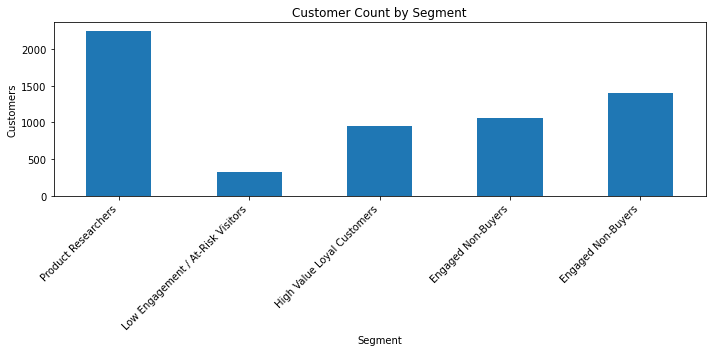

In [14]:
segment_profile.plot(
    x='segment_name',
    y='customers',
    kind='bar',
    figsize=(10, 5),
    legend=False
)
plt.title('Customer Count by Segment')
plt.xlabel('Segment')
plt.ylabel('Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


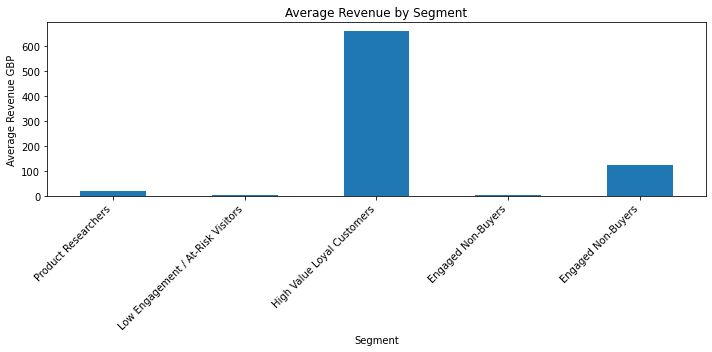

In [15]:
segment_profile.plot(
    x='segment_name',
    y='avg_revenue_gbp',
    kind='bar',
    figsize=(10, 5),
    legend=False
)
plt.title('Average Revenue by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Revenue GBP')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


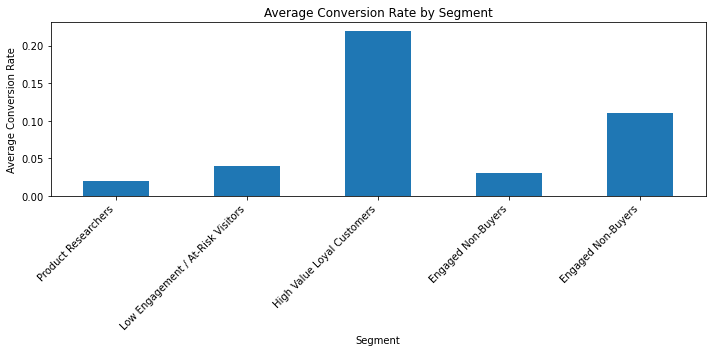

In [16]:
segment_profile.plot(
    x='segment_name',
    y='avg_conversion_rate',
    kind='bar',
    figsize=(10, 5),
    legend=False
)
plt.title('Average Conversion Rate by Segment')
plt.xlabel('Segment')
plt.ylabel('Average Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 11. PCA Cluster Visualization

PCA is used only to visualize high-dimensional customer clusters in two dimensions.


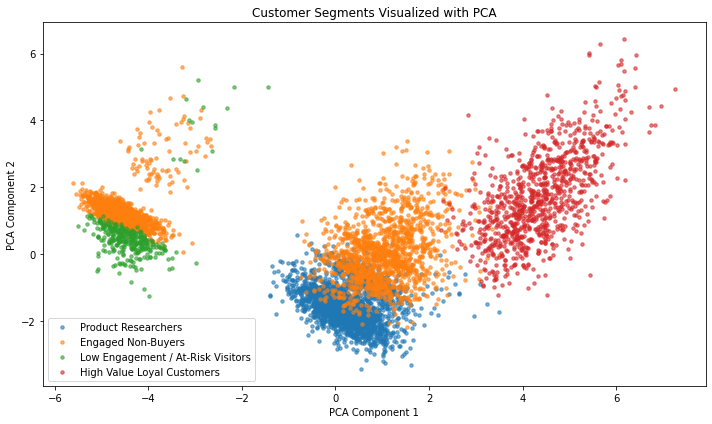

In [17]:
pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'pca_1': components[:, 0],
    'pca_2': components[:, 1],
    'segment_name': df['segment_name']
})

plt.figure(figsize=(10, 6))
for segment in pca_df['segment_name'].unique():
    temp = pca_df[pca_df['segment_name'] == segment]
    plt.scatter(temp['pca_1'], temp['pca_2'], s=12, alpha=0.6, label=segment)

plt.title('Customer Segments Visualized with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()


## 12. Business Strategy by Segment

### High Value Loyal Customers
- Highest revenue and strongest conversion behaviour
- Frequent sessions, high engagement, and strong purchase intent
- **Recommended strategy:** loyalty rewards, early access, VIP campaigns, personalized premium product recommendations, and retention-focused CRM journeys

### Product Researchers
- High product browsing behaviour but comparatively lower conversion
- Customers are showing intent but need more confidence or better offers
- **Recommended strategy:** remarketing campaigns, product comparison content, reviews, social proof, urgency messaging, and improved product-page UX

### Deal-Driven Converters
- Customers convert when there is a strong incentive or offer
- Useful for tactical campaigns but discounts should be margin-aware
- **Recommended strategy:** controlled promotions, personalized coupons, email triggers, and suppression of unnecessary discounts for customers likely to buy anyway

### Engaged Non-Buyers
- Strong engagement but weak purchase completion
- Potential friction exists in basket, checkout, pricing, delivery, or product confidence
- **Recommended strategy:** basket recovery, UX testing, checkout analysis, personalized recommendations, and A/B testing of CTA placement

### Low Engagement / At-Risk Visitors
- Low engagement, higher bounce, and weaker recent activity
- Lower commercial value unless reactivated efficiently
- **Recommended strategy:** low-cost reactivation, exclude from expensive paid retargeting, improve landing page relevance, and test win-back campaigns


## 13. Save Outputs


In [18]:
segment_profile.to_csv('../reports/segment_profile_from_notebook.csv', index=False)
df.to_csv('../reports/customers_with_segments_from_notebook.csv', index=False)

print('Notebook execution complete.')
print('Files saved in reports folder.')


Notebook execution complete.
Files saved in reports folder.
